# Residual Loader Resize Demo

This notebook shows how `pipeline.ResidualLoader.make_residual_dataloader(...)` behaves with and without `resize_hw`.

The key point is that resize happens during image load, before residuals and masks are computed, so every returned tensor uses the resized resolution.


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import torch

workspace_root = Path.cwd()
if (workspace_root / "pipeline").exists():
    project_root = workspace_root
elif (workspace_root / "Specular-Highlights" / "pipeline").exists():
    project_root = workspace_root / "Specular-Highlights"
else:
    raise RuntimeError("Could not locate the Specular-Highlights project root from the current working directory.")

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from pipeline import ResidualLoader as residual_loader

dataset_root = project_root.parent / "PSD_Dataset" / "PSD_Dataset" / "PSD_Train"
diffuse_images = dataset_root / "PSD_Train_diffuse"
glossy_images = dataset_root / "PSD_Train_specular"

print("Project root:", project_root)
print("Diffuse dir exists:", diffuse_images.exists(), diffuse_images)
print("Glossy dir exists:", glossy_images.exists(), glossy_images)


Project root: /Users/27171653/Desktop/PhD/Highlight-modelling/Specular-Highlights
Diffuse dir exists: True /Users/27171653/Desktop/PhD/Highlight-modelling/PSD_Dataset/PSD_Dataset/PSD_Train/PSD_Train_diffuse
Glossy dir exists: True /Users/27171653/Desktop/PhD/Highlight-modelling/PSD_Dataset/PSD_Dataset/PSD_Train/PSD_Train_specular


In [2]:
def _to_hwc(tensor: torch.Tensor):
    return tensor.detach().cpu().permute(1, 2, 0).clamp(0.0, 1.0).numpy()


def _single_channel(tensor: torch.Tensor):
    return tensor.detach().cpu().squeeze().numpy()


def _residual_for_display(tensor: torch.Tensor):
    tensor = tensor.detach().cpu()
    tensor = tensor - tensor.min()
    tensor = tensor / tensor.max().clamp_min(1e-8)
    return tensor.permute(1, 2, 0).numpy()


def inspect_resize(resize_hw=None, sample_idx=0, batch_size=1):
    dataset, loader = residual_loader.make_residual_dataloader(
        diffuse_dir=diffuse_images,
        glossy_dir=glossy_images,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        resize_hw=resize_hw,
        soft_gamma=1.0,
        threshold_method="otsu",
        threshold=0.7,
        residual_mode="additive",
        fill_holes=False
    )

    sample = dataset[sample_idx]
    batch = next(iter(loader))

    print("resize_hw:", resize_hw)
    print("dataset length:", len(dataset))
    print("sample name:", sample["name"])
    print("sample[input].shape:", tuple(sample["input"].shape))
    print("sample[diffuse].shape:", tuple(sample["diffuse"].shape))
    print("sample[unmasked_residual].shape:", tuple(sample["unmasked_residual"].shape))
    print("sample[soft_mask].shape:", tuple(sample["soft_mask"].shape))
    print("sample[mask].shape:", tuple(sample["mask"].shape))
    print("batch[input].shape:", tuple(batch["input"].shape))
    print("batch[diffuse].shape:", tuple(batch["diffuse"].shape))
    print("batch[unmasked_residual].shape:", tuple(batch["unmasked_residual"].shape))

    fig, axes = plt.subplots(1, 5, figsize=(18, 4))
    axes[0].imshow(_to_hwc(sample["input"]))
    axes[0].set_title("Input")
    axes[1].imshow(_to_hwc(sample["diffuse"]))
    axes[1].set_title("Diffuse")
    axes[2].imshow(_residual_for_display(sample["unmasked_residual"]))
    axes[2].set_title("Residual")
    axes[3].imshow(_single_channel(sample["soft_mask"]), cmap="magma")
    axes[3].set_title("Soft Mask")
    axes[4].imshow(_single_channel(sample["mask"]), cmap="gray")
    axes[4].set_title("Binary Mask")

    for ax in axes:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

    return dataset, loader, sample, batch


## Original Resolution

With `resize_hw=None`, the loader returns the images at their on-disk resolution.


resize_hw: None
dataset length: 361
sample name: filtered-0001.png
sample[input].shape: (3, 512, 768)
sample[diffuse].shape: (3, 512, 768)
sample[unmasked_residual].shape: (3, 512, 768)
sample[soft_mask].shape: (1, 512, 768)
sample[mask].shape: (1, 512, 768)
batch[input].shape: (1, 3, 512, 768)
batch[diffuse].shape: (1, 3, 512, 768)
batch[unmasked_residual].shape: (1, 3, 512, 768)


/Users/27171653/Library/Python/3.12/lib/python/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


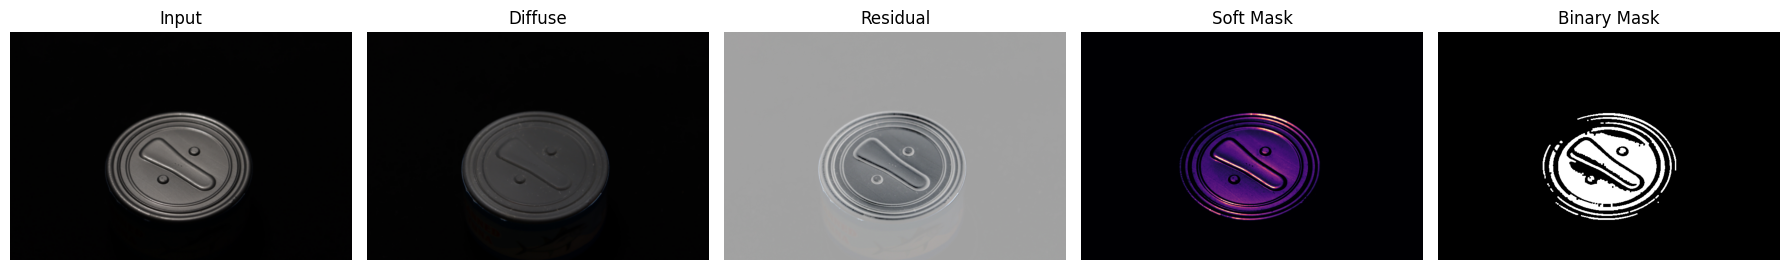

In [3]:
dataset_original, loader_original, sample_original, batch_original = inspect_resize(resize_hw=None)


## Square Resize

Passing an `int` or a square tuple gives square outputs.


resize_hw: 64
dataset length: 361
sample name: filtered-0001.png
sample[input].shape: (3, 64, 64)
sample[diffuse].shape: (3, 64, 64)
sample[unmasked_residual].shape: (3, 64, 64)
sample[soft_mask].shape: (1, 64, 64)
sample[mask].shape: (1, 64, 64)
batch[input].shape: (1, 3, 64, 64)
batch[diffuse].shape: (1, 3, 64, 64)
batch[unmasked_residual].shape: (1, 3, 64, 64)


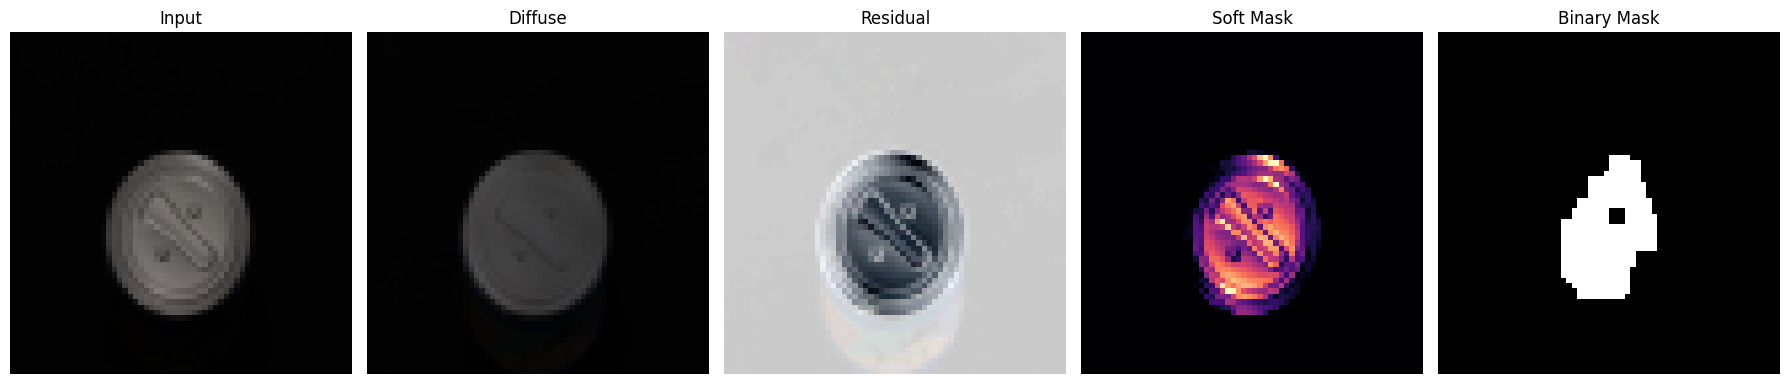

In [4]:
dataset_64, loader_64, sample_64, batch_64 = inspect_resize(resize_hw=64)


## Non-Square Resize

You can also pass a length-2 tuple `(height, width)`.


resize_hw: (64, 96)
dataset length: 361
sample name: filtered-0001.png
sample[input].shape: (3, 64, 96)
sample[diffuse].shape: (3, 64, 96)
sample[unmasked_residual].shape: (3, 64, 96)
sample[soft_mask].shape: (1, 64, 96)
sample[mask].shape: (1, 64, 96)
batch[input].shape: (1, 3, 64, 96)
batch[diffuse].shape: (1, 3, 64, 96)
batch[unmasked_residual].shape: (1, 3, 64, 96)


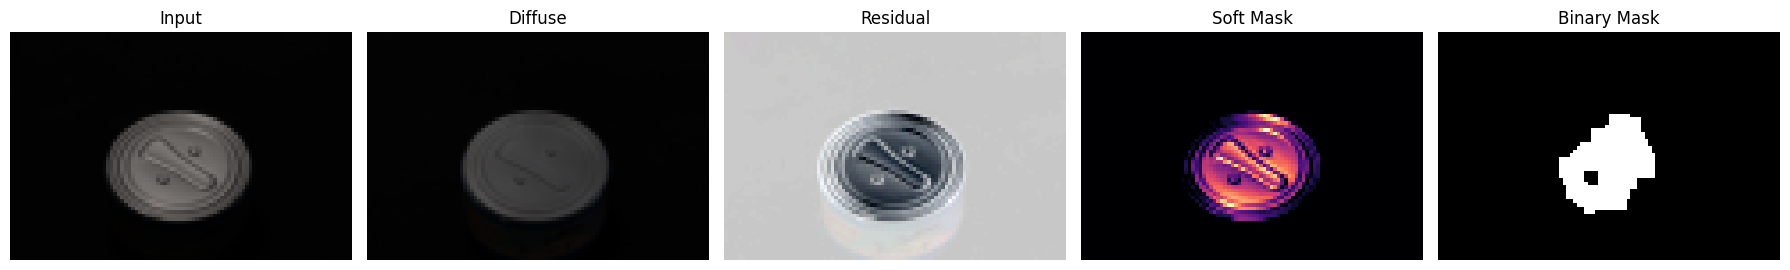

In [5]:
dataset_rect, loader_rect, sample_rect, batch_rect = inspect_resize(resize_hw=(64, 96))


resize_hw: (96, 128)
dataset length: 361
sample name: filtered-0001.png
sample[input].shape: (3, 96, 128)
sample[diffuse].shape: (3, 96, 128)
sample[unmasked_residual].shape: (3, 96, 128)
sample[soft_mask].shape: (1, 96, 128)
sample[mask].shape: (1, 96, 128)
batch[input].shape: (1, 3, 96, 128)
batch[diffuse].shape: (1, 3, 96, 128)
batch[unmasked_residual].shape: (1, 3, 96, 128)


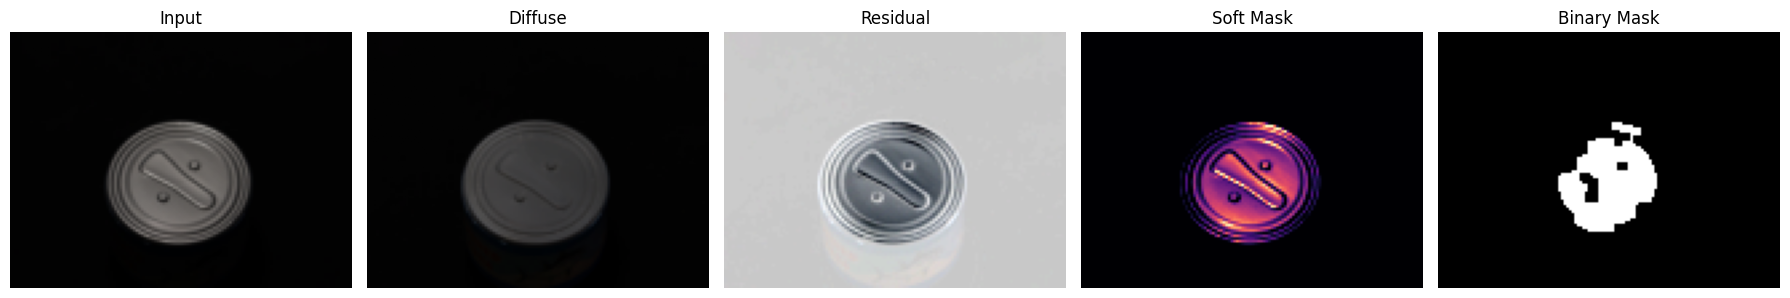

In [6]:
# Change this to try any resolution you want.
# Examples: 128, (96, 128), (256, 256)
custom_resize_hw = (96, 128)
dataset_custom, loader_custom, sample_custom, batch_custom = inspect_resize(resize_hw=custom_resize_hw)
